In [1]:
#from graph_transformer_long_range_niches.tl.wandb import load_and_log
from graph_transformer_long_range_niches._paths import CFG_FILES, HE22_HUMAN_LUNG_DATA_PATH
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.tl.utils import pad_batch
from graph_transformer_long_range_niches.tl.evaluation import eval_gnntransformer, extract_attention
from graph_transformer_long_range_niches.pl.color_map import CustomColormap
from graph_transformer_long_range_niches.pp.geome_utils import prepare_geome_dataset
from graph_transformer_long_range_niches.config import load_config
from graph_transformer_long_range_niches.pl.attention_matrix import plot_attention_sender_receiver

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

# Utility functions

In [8]:
def read(data_dir, split):
    """ Read PyG data from artifact folder
    """
    filename = split + ".pt"
    pyg_data = torch.load(os.path.join(data_dir, filename))
    return pyg_data # list with PyG Data objects

In [9]:
# subset adata to validation set
def subset_adata(pyg_datas, adata):
    """
    Subset adata according to the obs_names in a pyg object
    """
    sub_obs_names = []
    sub_adata = []
    for i, pyg in enumerate(pyg_datas):
        sub_obs_names.append(pyg.obs_names.numpy().astype(int).astype(str).tolist())
        sub_adata.append(adata[adata.obs_names.isin(sub_obs_names[i])])
    return sub_adata

# Global parameters

In [10]:
plt.rcParams['figure.figsize'] = (30, 20)

In [11]:
artifact_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts'
cfg_path = Path(CFG_FILES, 'pancreas_gnntrans_ct.yaml')
cfg = load_config(cfg_path)

In [12]:
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 300 # If 'figure', uses the figure's dpi value.
SMALL_SIZE = 17
MEDIUM_SIZE = 19
BIGGER_SIZE = 21
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [13]:
# set up path for figure saving
FIG_DIR = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures'
sc.settings.figdir = str(FIG_DIR)

## Load data

In [14]:
data_name = f"{cfg.dataset.name}_{cfg.dataset.prediction_obs}_{cfg.dataset.library_key}"
model_name = f"{data_name}_{cfg.model.model_type}"
run_name = f"download_{data_name}"

In [15]:
model_path = f'{artifact_dir}/{model_name}_model:v3/{model_name}.ckpt'
checkpoint = torch.load(model_path)
cfg = checkpoint['hyper_parameters']['cfg']
cfg.set_new_allowed(True)
cfg.defrost()
cfg.dataset.prediction_task = 'node_classification'
cfg.freeze()
model = LitGNNTransformer(cfg)
model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

In [16]:
data_dir = f"{artifact_dir}/{data_name}:v2" #TODO: adjust to downloaded dataset
pyg_data_val = read(data_dir, 'validation')
pyg_data_val[:3]

[Data(x=[561, 979], edge_index=[2, 340], y=[561, 9], obs_names=[561]),
 Data(x=[754, 979], edge_index=[2, 904], y=[754, 9], obs_names=[754]),
 Data(x=[685, 979], edge_index=[2, 696], y=[685, 9], obs_names=[685])]

In [17]:
adata = read(data_dir, 'adata')
adata

AnnData object with n_obs × n_vars = 108711 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial', 'one_hot_mappings'
    obsm: 'spatial', 'spatial_fov', 'one_hot'
    layers: 'counts'

In [22]:
pyg_data_val = read(data_dir, 'training')
for i in range(len(pyg_data_val)):
    filtered_adata = adata[pyg_data_val[i].obs_names.numpy().astype(int), :].copy()
    print(i, np.unique(filtered_adata.obs.fov), np.unique(filtered_adata.obs.condition), np.unique(filtered_adata.obs.sliding_window))

0 ['6'] ['T1D'] ['6_2_0']
1 ['15'] ['ND'] ['15_0_1']
2 ['2'] ['T1D'] ['2_1_0']
3 ['16'] ['ND'] ['16_0_0']
4 ['12'] ['ND'] ['12_2_0']
5 ['11'] ['T1D'] ['11_2_0']
6 ['24'] ['ND'] ['24_1_1']
7 ['4'] ['T1D'] ['4_1_1']
8 ['17'] ['ND'] ['17_0_0']
9 ['5'] ['T1D'] ['5_2_0']
10 ['7'] ['T1D'] ['7_0_1']
11 ['2'] ['T1D'] ['2_0_0']
12 ['1'] ['T1D'] ['1_0_0']
13 ['10'] ['T1D'] ['10_0_0']
14 ['23'] ['ND'] ['23_0_0']
15 ['14'] ['ND'] ['14_2_0']
16 ['16'] ['ND'] ['16_2_0']
17 ['23'] ['ND'] ['23_1_0']
18 ['14'] ['ND'] ['14_0_0']
19 ['14'] ['ND'] ['14_0_1']
20 ['13'] ['ND'] ['13_2_1']
21 ['5'] ['T1D'] ['5_0_1']
22 ['20'] ['ND'] ['20_0_1']
23 ['17'] ['ND'] ['17_1_0']
24 ['12'] ['ND'] ['12_1_1']
25 ['24'] ['ND'] ['24_2_1']
26 ['16'] ['ND'] ['16_1_1']
27 ['13'] ['ND'] ['13_2_0']
28 ['20'] ['ND'] ['20_1_0']
29 ['22'] ['ND'] ['22_1_0']
30 ['9'] ['T1D'] ['9_1_0']
31 ['17'] ['ND'] ['17_2_1']
32 ['15'] ['ND'] ['15_0_0']
33 ['4'] ['T1D'] ['4_2_0']
34 ['21'] ['ND'] ['21_2_0']
35 ['8'] ['T1D'] ['8_2_1']
36 ['15'] [

# Spatial distribution of evaluation data

In [30]:
#cm = CustomColormap(np.insert(np.unique(adata.obs['cell_type_coarse']), 0, 'None'), none_color='#D3D3D3', cmap_name='he23_niche_custom')

In [108]:
obs_name = 'sliding_window'
obs_nr = '12_1_1'
subadata = adata[adata.obs[obs_name] == obs_nr]
subadata

View of AnnData object with n_obs × n_vars = 885 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial', 'one_hot_mappings'
    obsm: 'spatial', 'spatial_fov', 'one_hot'
    layers: 'counts'

In [109]:
subadata.uns['cell_type_coarse_colors'] = [
    '#edd892', #acinar
    '#219ebc', #alpha
    '#adc178', #beta
    '#f79824', #ductal
    '#718355', #endocrine
    '#f15156', #endothelial
    '#bbd0ff', #Fibroblasts
    '#979dac', #Immune
    #'#582f0e'  #mast
]
subadata.uns['sliding_window_colors'] = [
    '#001219',
    '#005F73',
    '#0A9396',
    '#94D2BD',
    '#E9D8A6',
    '#EE9B00'
]

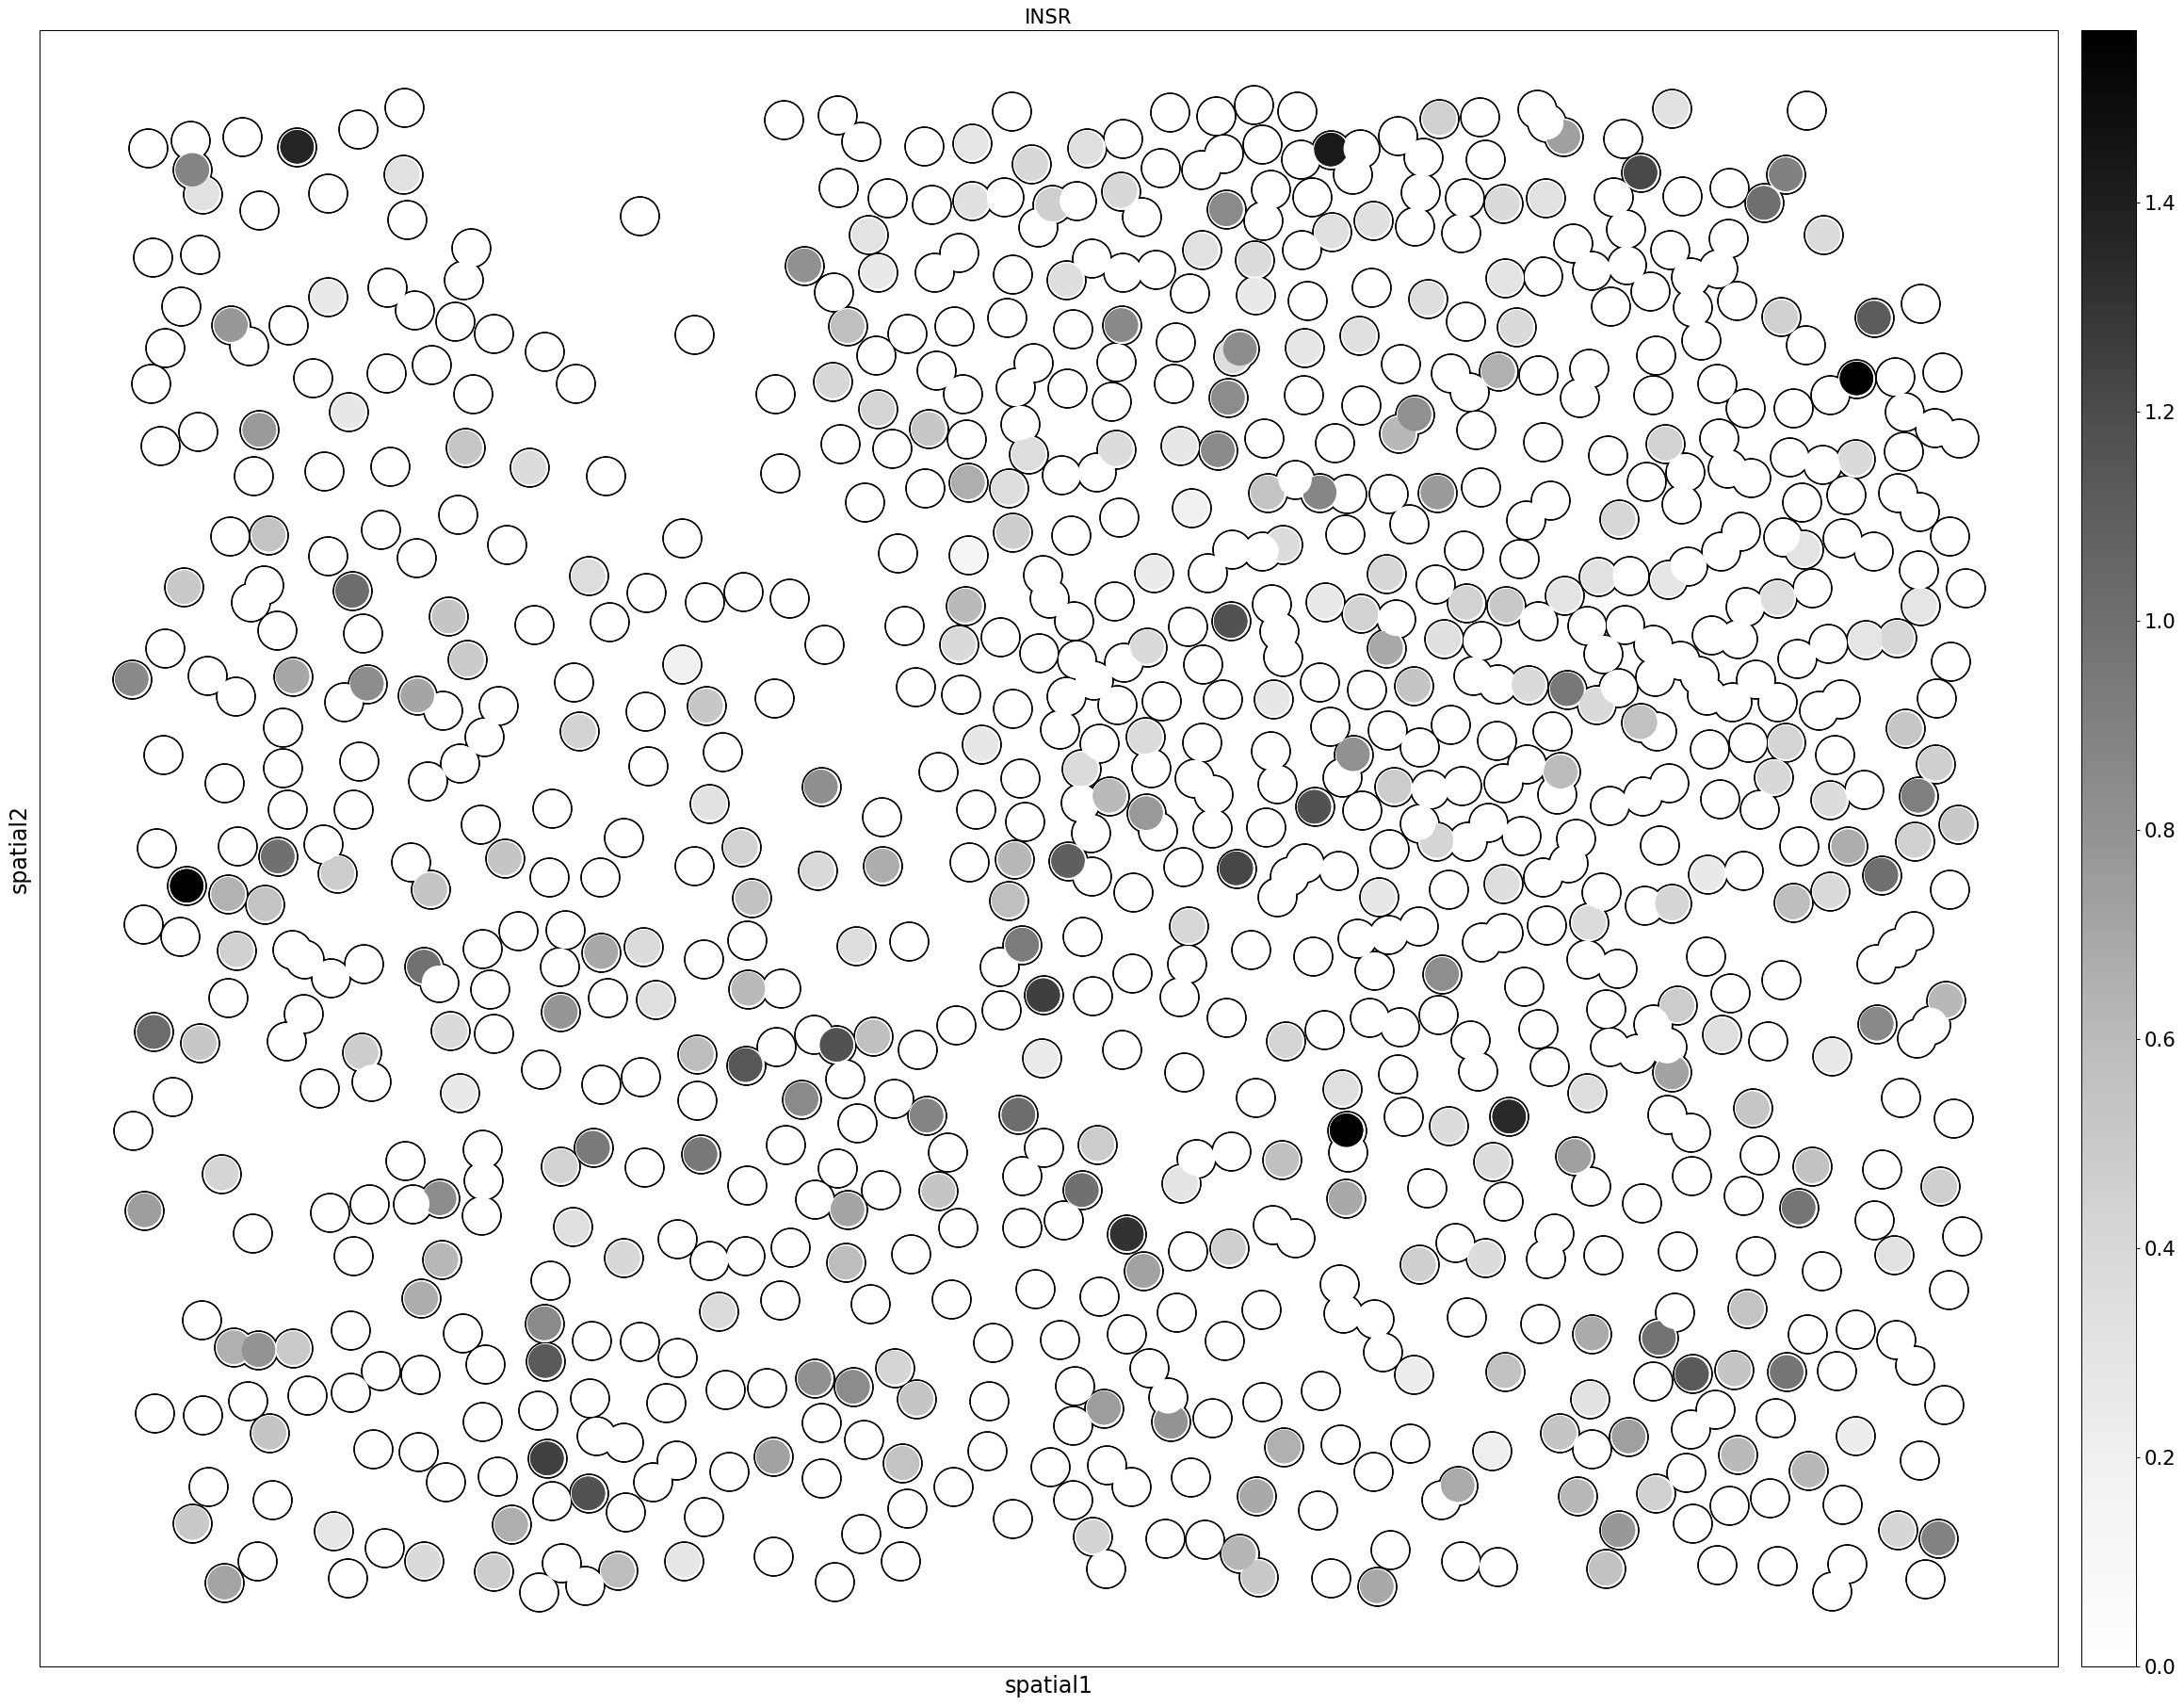

In [125]:
color_obs = 'INSR'
sq.pl.spatial_scatter(
                subadata,
                color = color_obs,
                spatial_key = 'spatial',
                shape=None,
                #library_key='sliding_window', 
                size = 3000, 
    outline= True,
    outline_width=(0.05,0.05),
    cmap = "Greys",
    save = f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/pancreas_{obs_name}_{obs_nr}_{color_obs}.png'
)

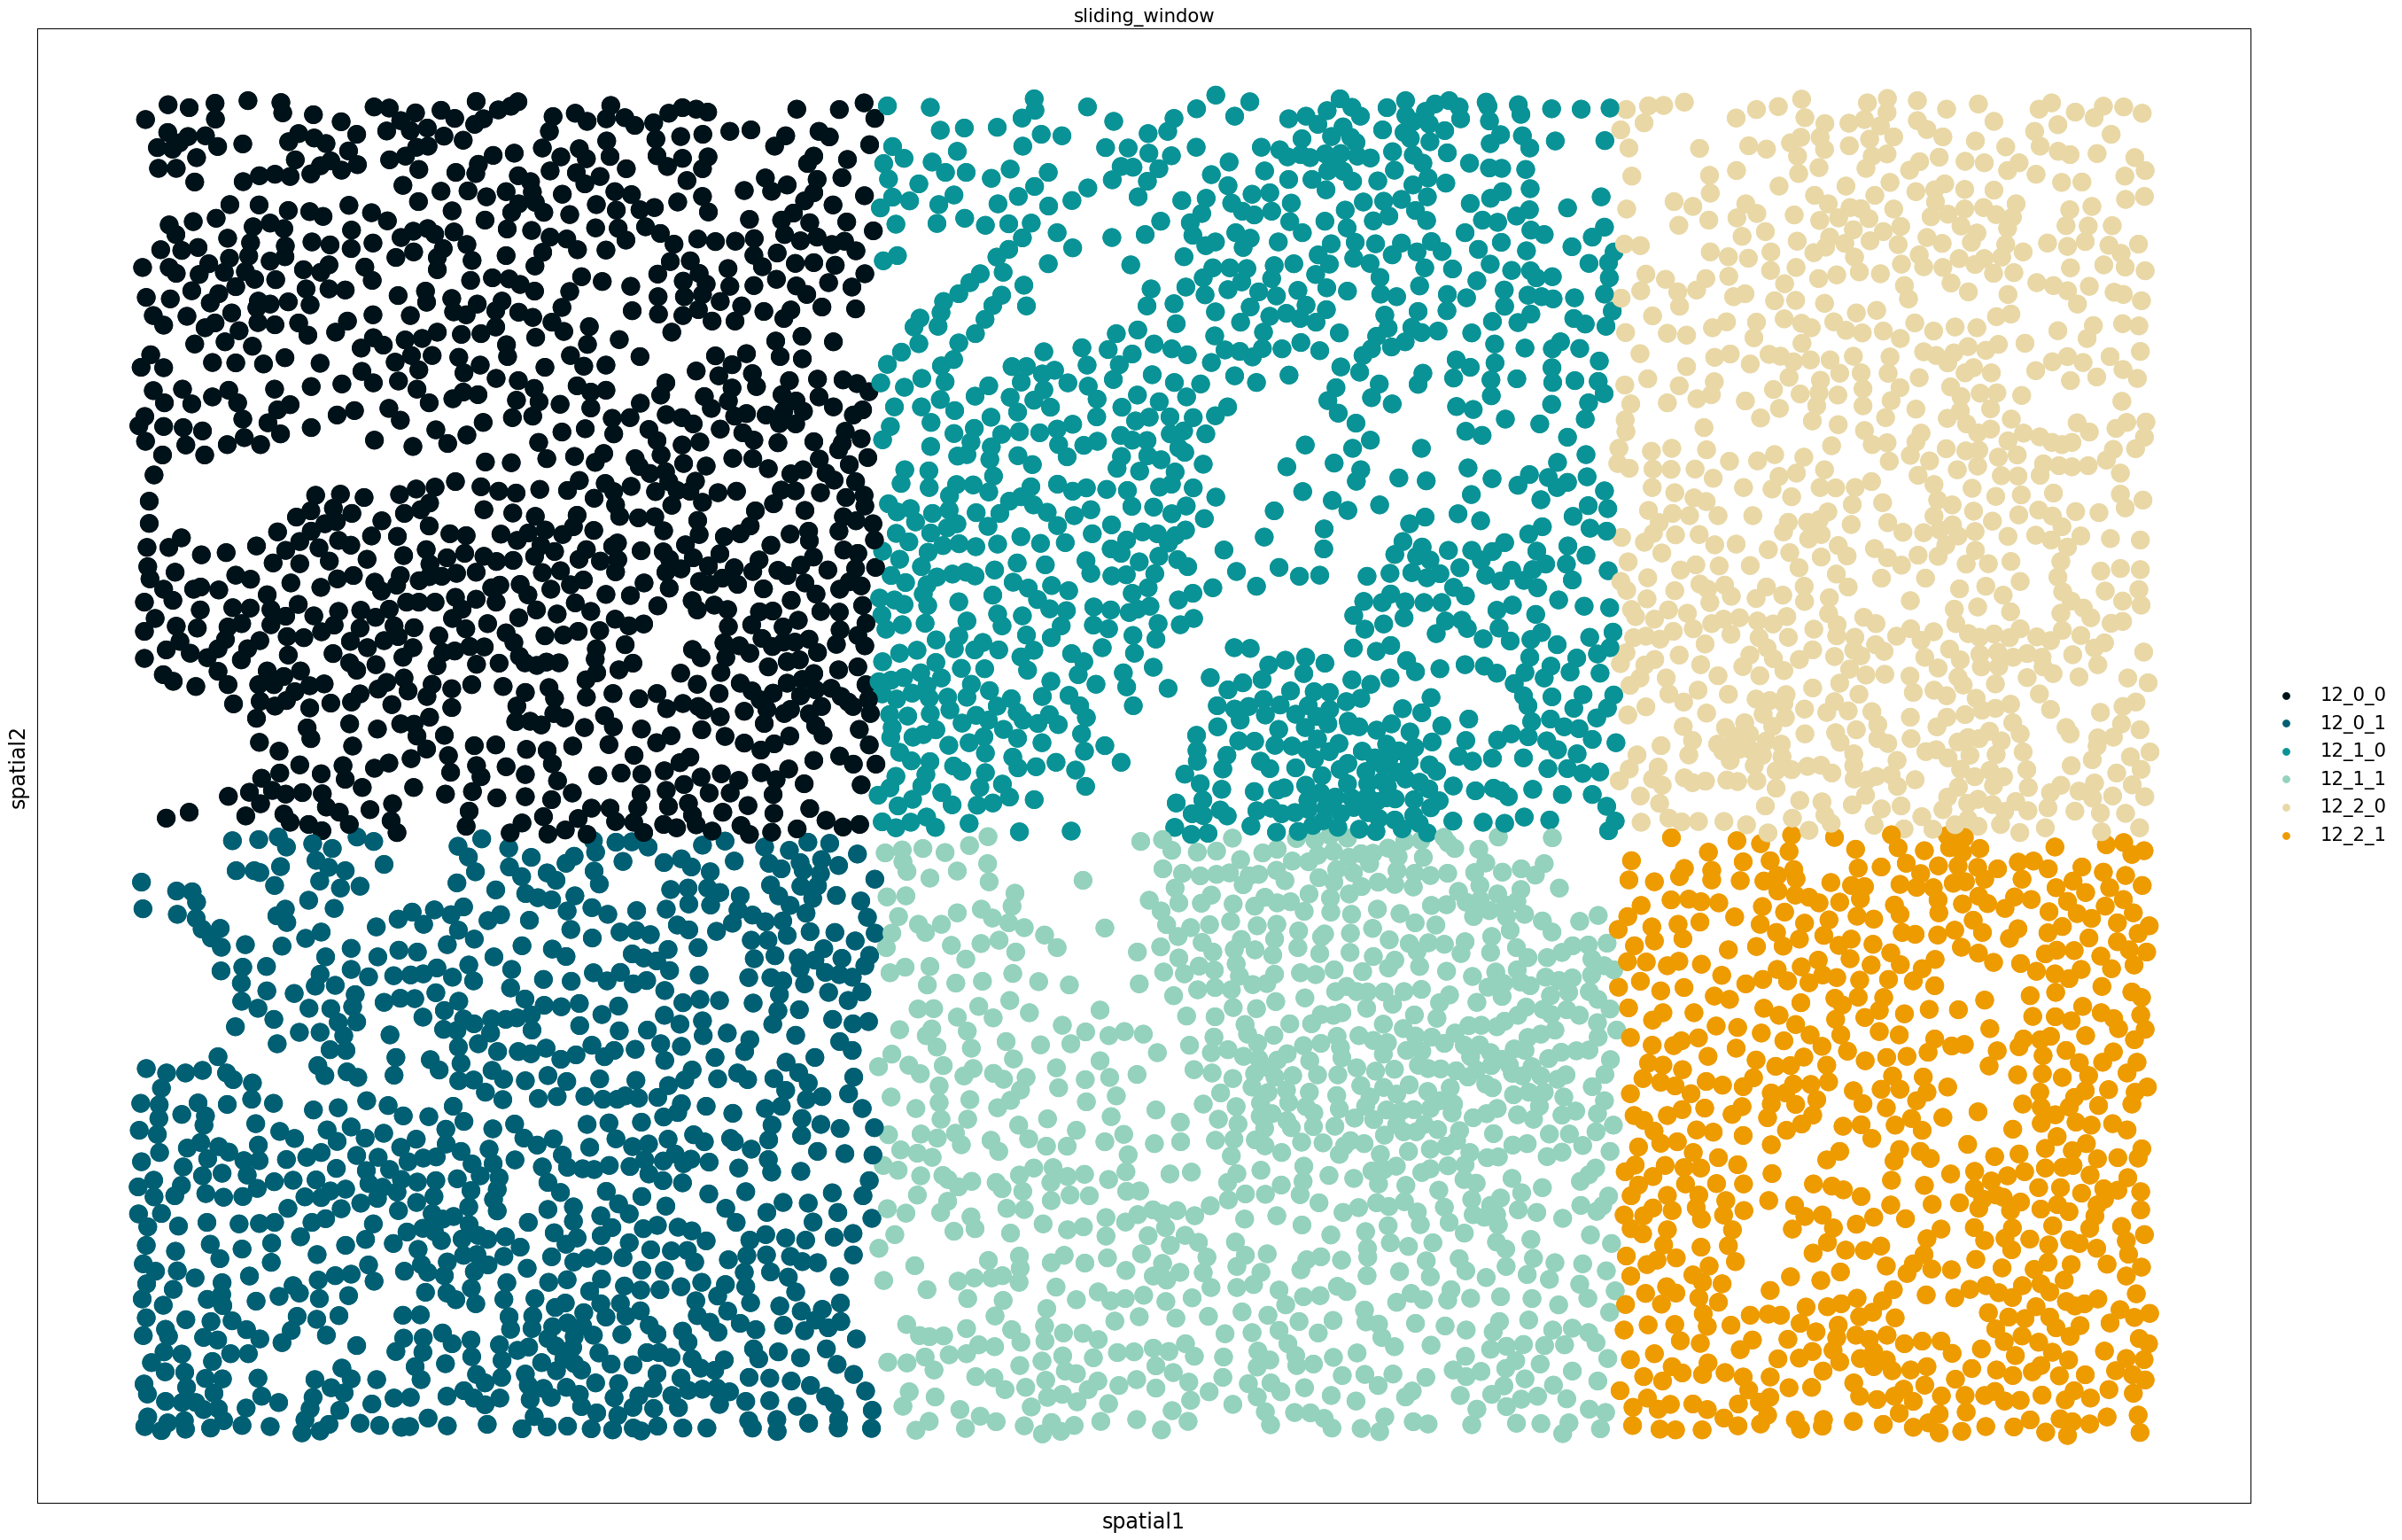

In [27]:
color_obs = 'sliding_window'
sq.pl.spatial_scatter(
                subadata,
                color = 'sliding_window',
                spatial_key = 'spatial',
                shape=None,
                library_key='fov', 
                size = 2000, 
    save = f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/pancreas_{obs_name}_{obs_nr}_{color_obs}.png'
)

# Evaluation on validation data

In [33]:
val_adata_list = subset_adata(pyg_data_val, adata)
val_adata_list[:3]

[View of AnnData object with n_obs × n_vars = 668 × 979
     obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window'
     var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
     uns: 'log1p', 'spatial', 'one_hot_mappings'
     obsm: 'spatial', 'spatial_fov', 'one_hot'
     layers: 'counts',
 View of AnnData object with n_obs × n_vars = 846 × 979
    

transformer in: torch.Size([885, 1, 128]), out: torch.Size([886, 1, 128])
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune']


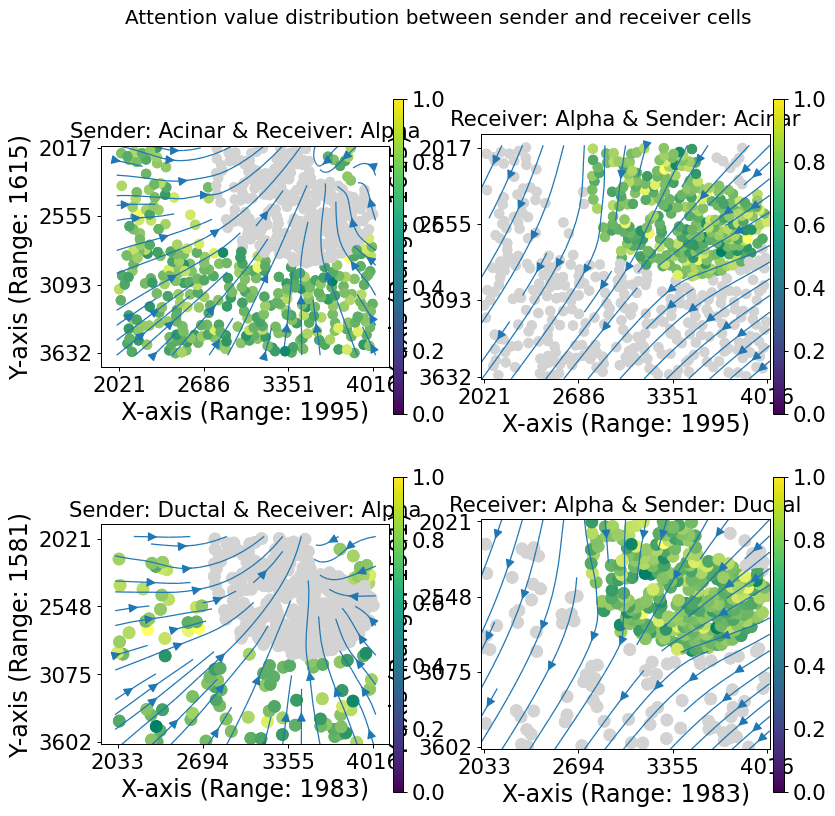

In [126]:
start, end = 24,25 # FOV: 12
#start, end = 62,63 # FOV: 10
eval_loader = DataLoader(pyg_data_val[start:end], 1)
for i, batch in enumerate(eval_loader):
    #transformer_in, transformer_out, src_padding_mask, index_nodes = eval_gnntransformer(model, batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes = model.evaluation(model, batch)
    print(f'transformer in: {transformer_in.shape}, out: {transformer_out.shape}')
    attn_maps, attn_weights_maps = extract_attention(model.transformer_encoder, transformer_out, src_padding_mask)
    val_adata = val_adata_list[i+start]
    sub_obs_names = val_adata.obs_names[index_nodes[0]]
    str_list = [i for i in sub_obs_names]
    val_adata = val_adata[val_adata.obs_names.isin(str_list)].copy()
    val_adata.obsm["attention_matrix"] = attn_weights_maps[0].squeeze(0)[1:, 1:].numpy()
    print(np.unique(val_adata.obs['cell_type_coarse']))
    sender = 'Alpha'
    plot_attention_sender_receiver(val_adata, ['Acinar', 'Ductal'], sender, cell_type_key = 'cell_type_coarse', attn_matrix_key='attention_matrix', add_streamline = True, discrete_values=True, show_index = True, save_img = f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/pancreas_sliding_window_12_1_1_{sender}.png')

In [13]:
val_adata.obsm["attention_matrix"]

array([[0.00071326, 0.00034441, 0.00105364, ..., 0.00104054, 0.00100124,
        0.00029586],
       [0.00109953, 0.00072031, 0.00107519, ..., 0.00073488, 0.00140116,
        0.00099985],
       [0.00138888, 0.00101722, 0.00068289, ..., 0.00140468, 0.0003649 ,
        0.00107993],
       ...,
       [0.00071841, 0.00068729, 0.00138679, ..., 0.00108176, 0.00030689,
        0.00142962],
       [0.00109362, 0.00144418, 0.00104269, ..., 0.00076805, 0.00139743,
        0.00097664],
       [0.00067376, 0.00070921, 0.00105104, ..., 0.0006884 , 0.00107153,
        0.00109912]], dtype=float32)

## Var by distance

In [127]:
current_sender = 'Beta'
current_receiver = "Acinar"
cell_type_key = "cell_type_coarse"

In [128]:
val_adata

AnnData object with n_obs × n_vars = 885 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial', 'one_hot_mappings'
    obsm: 'spatial', 'spatial_fov', 'one_hot', 'attention_matrix'
    layers: 'counts'

In [129]:
def calculate_attention_values(adata, 
                               cell_type_key: str = 'cell_type',
                               attn_matrix_key: str ='attention_matrix'):
    """
    Calculates the average attention values from the attention matrix 
    from each cell to receiver cell type, normalizes within classes, 
    and saves the results in `adata.obs` as 'attention_value_RECEIVER-CT'.
    """
    # Extract attention matrix and cell type information
    attention_matrix = adata.obsm[attn_matrix_key].copy()
    obs_names = adata.obs[cell_type_key]
    
    # Convert attention matrix to DataFrame for easier manipulation
    attention_matrix = pd.DataFrame(attention_matrix, index=obs_names, columns=obs_names)
    
    # Get unique classes
    unique_classes = obs_names.unique()
    
    # Initialize an empty DataFrame to store normalized attention values
    normalized_attentions = pd.DataFrame(index=attention_matrix.index)

    cell_type_attentions = {}
    cell_type_attentions_df = pd.DataFrame(index=unique_classes, columns=unique_classes)

    # Iterate over each class to calculate and normalize attention values
    for sender_class in unique_classes:
        # Extract attention values for this class (sender -> receiver)
        class_attentions = attention_matrix.loc[sender_class, :]
        
        # Compute the mean attention value for each receiver within this class
        mean_attentions = class_attentions.mean(axis=0)
        
        if mean_attentions.min() == mean_attentions.max(): # skip if only one cell otherwise becomes NaN
            continue
        norm_attentions = (mean_attentions - mean_attentions.min()) / (mean_attentions.max() - mean_attentions.min()) # (min-max normalization)
        
        # Add normalized attention values to the DataFrame
        normalized_attentions[f'attention_value_{sender_class}'] = norm_attentions

        ## NORMALIZED ATTENTION FROM CELL TYPE TO CELL TYPE
        df = pd.DataFrame({f'values': norm_attentions.values, 'names': norm_attentions.index})
        
        # Group by the names and calculate the mean for each group
        grouped_means = df.groupby('names')[f'values'].mean() #ToDo: instead of creating new DF add to existing DF
        
        # Min-max normalization for the means
        normalized_means = (grouped_means - grouped_means.min()) / (grouped_means.max() - grouped_means.min())

        # Store the normalized mean values in the corresponding sender-receiver cell type locations
        cell_type_attentions_df.loc[sender_class, normalized_means.index] = normalized_means.values
        
    #print(cell_type_attentions_df)
    
    # Add the normalized attention values to `adata.obs`
    for attention_value in normalized_attentions.columns:
        adata.obs[attention_value] = normalized_attentions[attention_value].values

    return adata, cell_type_attentions_df.dropna()

val_adata, cell_type_attentions_df = calculate_attention_values(val_adata,cell_type_key,attn_matrix_key ='attention_matrix')
val_adata

AnnData object with n_obs × n_vars = 885 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window', 'attention_value_Acinar', 'attention_value_Fibroblasts', 'attention_value_Ductal', 'attention_value_Endothelial', 'attention_value_Immune', 'attention_value_Endocrine', 'attention_value_Alpha', 'attention_value_Beta'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log

In [70]:
cell_type_attentions_df

,Acinar,Ductal,Endothelial,Fibroblasts,Immune,Endocrine,Beta,Alpha,Mast
Acinar,0.466908,0.542017,0.381017,0.404469,0.299539,0.240105,0.245784,1.0,0.0
Ductal,0.514872,0.590861,0.450306,0.483929,0.190263,0.274322,0.251929,1.0,0.0
Endothelial,0.92694,1.0,0.770895,0.788935,0.675169,0.0,0.803302,0.735518,0.372365
Fibroblasts,0.495978,0.52406,0.329112,0.510826,0.369694,0.761125,0.360768,1.0,0.0
Immune,0.776684,0.956542,0.606222,0.776496,0.311123,1.0,0.9088,0.0,0.776843
Endocrine,0.305212,0.085278,0.589065,0.432307,0.519039,0.800839,0.0,0.110911,1.0
Beta,0.43176,0.510337,0.173231,0.484784,0.0,0.696234,0.027262,1.0,0.226262
Alpha,0.420646,0.427962,0.314027,0.38607,0.414272,0.0,0.495896,1.0,0.399227
Mast,0.547861,0.385991,0.423827,0.627946,1.0,0.09113,0.440292,0.674497,0.0


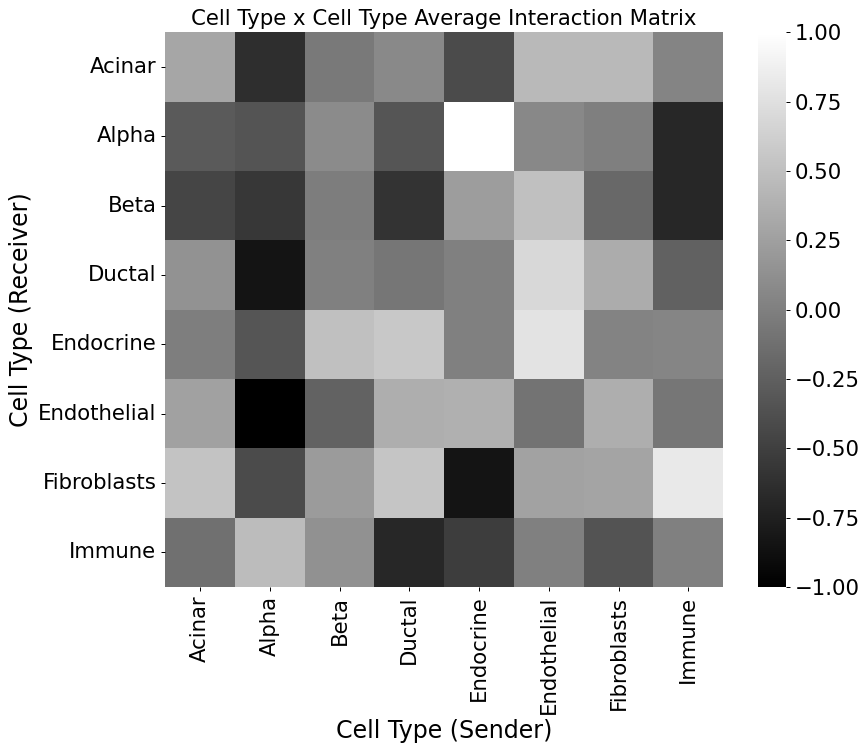

In [93]:
cell_type_attentions_df = cell_type_attentions_df.apply(pd.to_numeric, errors='coerce')  # Convert to numeric
plt.figure(figsize=(10, 8))
sns.heatmap(df, cmap = 'gray')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

In [83]:
cell_type_attentions_nd - cell_type_attentions_t1d

,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune,Mast
Acinar,0.298690,-0.639373,-0.053252,0.073177,-0.409292,0.449037,0.450251,0.036639,NaN
Alpha,-0.292918,-0.339885,0.092598,-0.329550,1.000000,0.067373,-0.004551,-0.687659,NaN
Beta,-0.457056,-0.570004,-0.015996,-0.599585,0.232740,0.503636,-0.180323,-0.689862,NaN
Ductal,0.147966,-0.840043,0.002607,-0.074676,0.000000,0.692360,0.351249,-0.238112,NaN
Endocrine,-0.009377,-0.328702,0.505287,0.567421,0.000000,0.780124,0.024626,0.040042,NaN
Endothelial,0.259699,-1.000000,-0.227641,0.366011,0.382576,-0.094420,0.361782,-0.073592,NaN
Fibroblasts,0.524674,-0.408516,0.215940,0.546660,-0.836087,0.268230,0.282331,0.820434,NaN
Immune,-0.120699,0.472113,0.140397,-0.690713,-0.517751,0.004973,-0.348429,0.000000,NaN
Mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df = cell_type_attentions_nd - cell_type_attentions_t1d
df = df.apply(pd.to_numeric, errors='coerce')
df = df.drop('Mast', axis = 0)
df = df.drop('Mast', axis = 1)

In [89]:
df

,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune
Acinar,0.298690,-0.639373,-0.053252,0.073177,-0.409292,0.449037,0.450251,0.036639
Alpha,-0.292918,-0.339885,0.092598,-0.329550,1.000000,0.067373,-0.004551,-0.687659
Beta,-0.457056,-0.570004,-0.015996,-0.599585,0.232740,0.503636,-0.180323,-0.689862
Ductal,0.147966,-0.840043,0.002607,-0.074676,0.000000,0.692360,0.351249,-0.238112
Endocrine,-0.009377,-0.328702,0.505287,0.567421,0.000000,0.780124,0.024626,0.040042
Endothelial,0.259699,-1.000000,-0.227641,0.366011,0.382576,-0.094420,0.361782,-0.073592
Fibroblasts,0.524674,-0.408516,0.215940,0.546660,-0.836087,0.268230,0.282331,0.820434
Immune,-0.120699,0.472113,0.140397,-0.690713,-0.517751,0.004973,-0.348429,0.000000


In [68]:
cell_type_attentions_nd - cell_type_attentions_t1d

,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune,Mast
Acinar,0.29869,-0.639373,-0.053252,0.073177,-0.409292,0.449037,0.450251,0.036639,NaN
Alpha,-0.292918,-0.339885,0.092598,-0.32955,1.0,0.067373,-0.004551,-0.687659,NaN
Beta,-0.457056,-0.570004,-0.015996,-0.599585,0.23274,0.503636,-0.180323,-0.689862,NaN
Ductal,0.147966,-0.840043,0.002607,-0.074676,0.0,0.69236,0.351249,-0.238112,NaN
Endocrine,-0.009377,-0.328702,0.505287,0.567421,0.0,0.780124,0.024626,0.040042,NaN
Endothelial,0.259699,-1.0,-0.227641,0.366011,0.382576,-0.09442,0.361782,-0.073592,NaN
Fibroblasts,0.524674,-0.408516,0.21594,0.54666,-0.836087,0.26823,0.282331,0.820434,NaN
Immune,-0.120699,0.472113,0.140397,-0.690713,-0.517751,0.004973,-0.348429,0.0,NaN
Mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
val_adata.obs[cell_type_key].value_counts()

cell_type_coarse
Acinar         313
Alpha          260
Fibroblasts    104
Ductal         100
Beta            62
Immune          19
Endothelial     17
Endocrine       10
Name: count, dtype: int64

<Figure size 2821.5x1800 with 0 Axes>

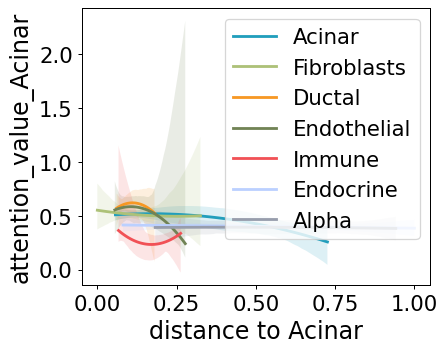

<Figure size 2821.5x1800 with 0 Axes>

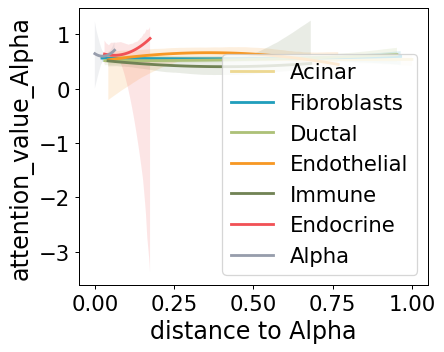

<Figure size 2821.5x1800 with 0 Axes>

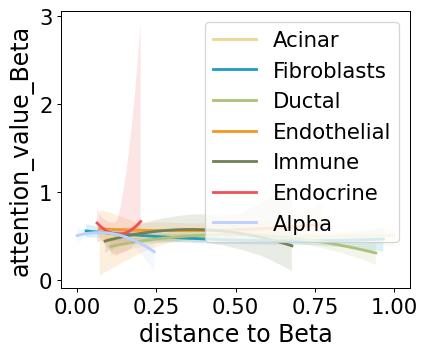

<Figure size 2821.5x1800 with 0 Axes>

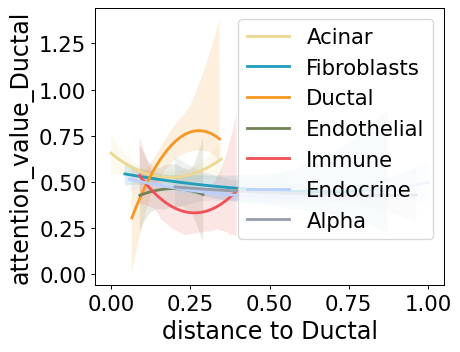

<Figure size 2821.5x1800 with 0 Axes>

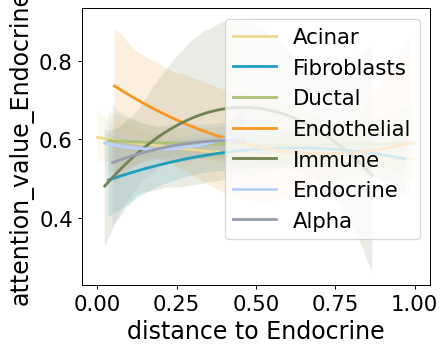

<Figure size 2821.5x1800 with 0 Axes>

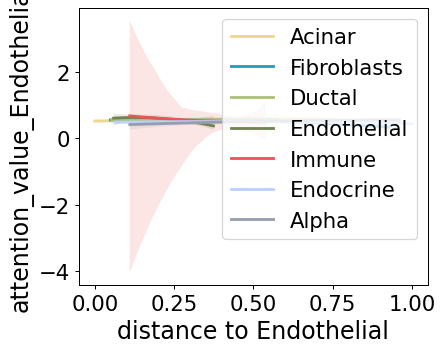

<Figure size 2821.5x1800 with 0 Axes>

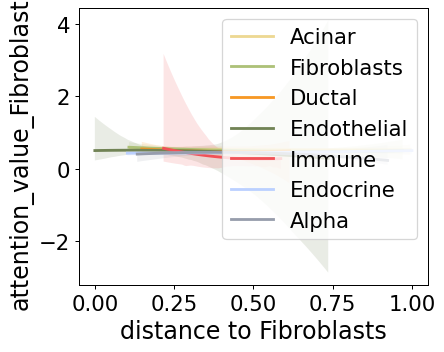

<Figure size 2821.5x1800 with 0 Axes>

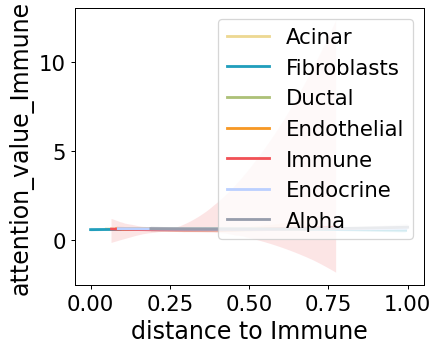

In [60]:
for class_name in np.unique(val_adata.obs[cell_type_key]):
    sq.tl.var_by_distance(
                    adata=val_adata,
                    groups=class_name,
                    cluster_key=cell_type_key,
                    library_key="sliding_window",
                    covariates = ['cell_type_coarse']
    )
    sq.pl.var_by_distance(
        adata=val_adata,
        design_matrix_key="design_matrix",
        covariate = 'cell_type_coarse',
        var=[f'attention_value_{class_name}'],
        line_palette=['#edd892','#219ebc','#adc178','#f79824','#718355','#f15156','#bbd0ff','#979dac','#582f0e'],
        anchor_key=class_name,
        show_scatter=False,
        figsize=(5, 4),
        order=2
        #regplot_kwargs = {'lowless':False},
    )

<Figure size 2821.5x1800 with 0 Axes>

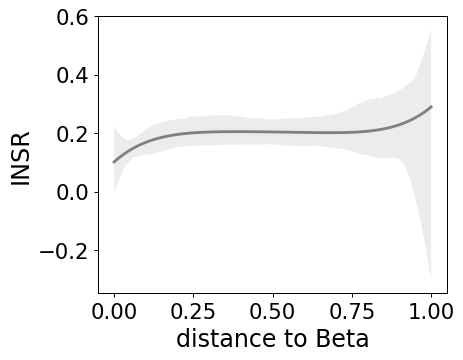

In [147]:
anchor_key = "Beta"
var = "INRS"
sq.tl.var_by_distance(
        adata=val_adata,
        groups=anchor_key,
        cluster_key=cell_type_key,
        library_key="sliding_window",
)
sq.pl.var_by_distance(
    adata=val_adata,
    design_matrix_key="design_matrix",
    var=['INSR'],
    anchor_key=anchor_key,
    line_palette="gray",
    show_scatter=False,
    figsize=(5, 4),
)
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/pancreas_{obs_name}_{obs_nr}_{anchor_key}_{var}.png')

<Figure size 2821.5x1800 with 0 Axes>

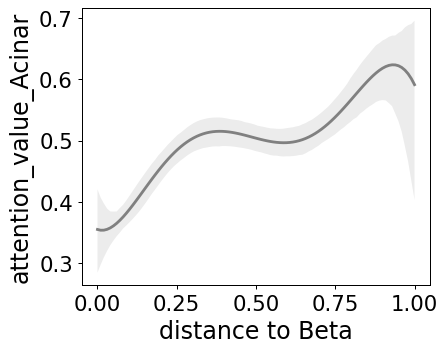

<Figure size 2821.5x1800 with 0 Axes>

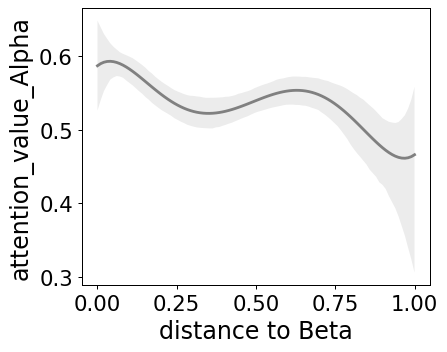

<Figure size 2821.5x1800 with 0 Axes>

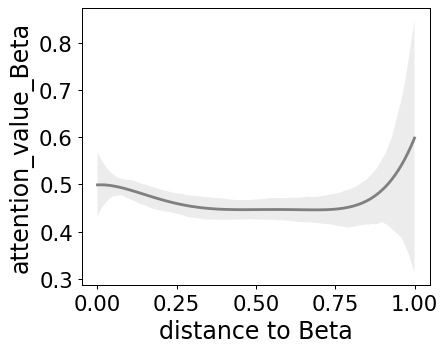

<Figure size 2821.5x1800 with 0 Axes>

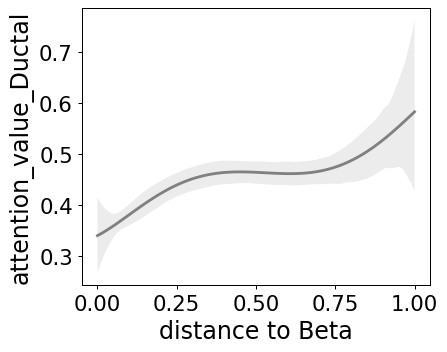

<Figure size 2821.5x1800 with 0 Axes>

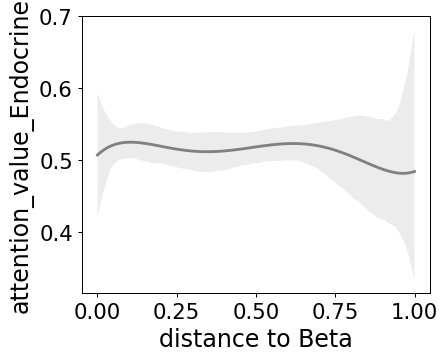

<Figure size 2821.5x1800 with 0 Axes>

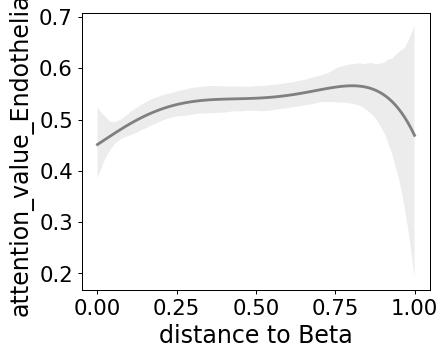

<Figure size 2821.5x1800 with 0 Axes>

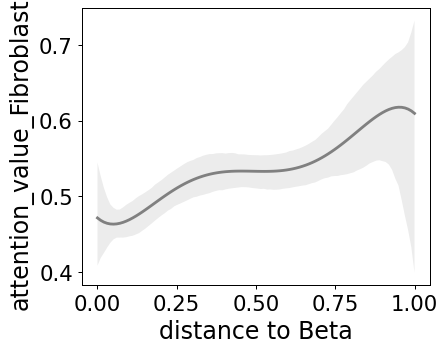

<Figure size 2821.5x1800 with 0 Axes>

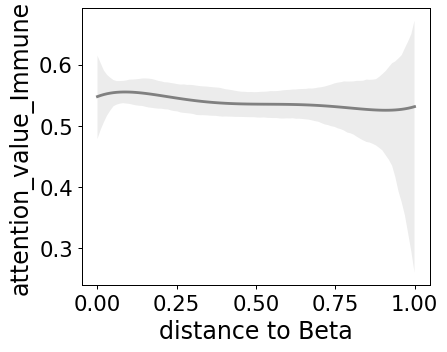

In [137]:
anchor_key = "Beta"
for class_name in np.unique(val_adata.obs[cell_type_key]):
    if str(f'attention_value_{class_name}') in val_adata.obs:
        sq.tl.var_by_distance(
                adata=val_adata,
                groups=anchor_key,
                cluster_key=cell_type_key,
                library_key="sliding_window",
        )
        sq.pl.var_by_distance(
            adata=val_adata,
            design_matrix_key="design_matrix",
            var=[f'attention_value_{class_name}'],
            anchor_key=anchor_key,
            line_palette="gray",
            show_scatter=False,
            figsize=(5, 4),
        )
    

(77,)
View of AnnData object with n_obs × n_vars = 526 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial', 'one_hot_mappings', 'design_matrix'
    obsm: 'spatial', 'spatial_fov', 'one_hot', 'attention_matrix', 'design_matrix'
    layers: 'counts'
95497  

95497   -10.726899
95499   -10.726899
95500   -10.726899
95501   -10.726899
95507   -10.726899
           ...    
98401   -10.726899
98402   -10.726899
98404   -10.726899
98405   -10.726899
98408   -10.726899
Name: attention_values_Beta_Acinar, Length: 526, dtype: float64

<Figure size 3135x2000 with 0 Axes>

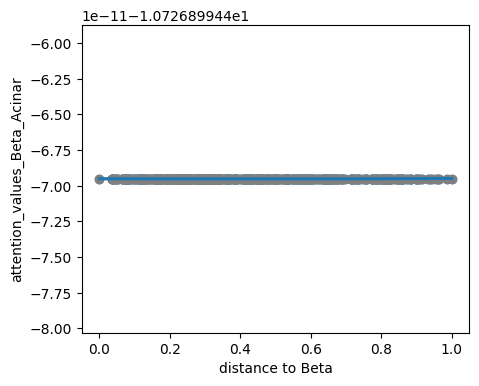

In [48]:
def calculate_attention_values(adata, sender_cell, receiver_cell,
                               cell_type_key: str = 'cell_type',
                               attn_matrix_key: str ='attention_matrix'):
    """Calculates the average attention values from the attention matrix from sender cell to receiver cell"""
    attention_matrix = val_adata.obsm["attention_matrix"].copy()
    obs_names = val_adata.obs[cell_type_key]
    attention_matrix = pd.DataFrame(attention_matrix, index=obs_names, columns=obs_names)
    attention_sums = attention_matrix.loc[sender_cell, receiver_cell].sum(axis=1)
    print(attention_sums.shape)
    subadata = adata[adata.obs[cell_type_key].isin([sender_cell, receiver_cell])] # subdata with only sender and receiver cells
    print(subadata)
    subadata.obs[f'attention_values_{sender_cell}_{receiver_cell}'] = 0
    subadata.obs.loc[subadata.obs[cell_type_key] == sender_cell, f'attention_values_{sender_cell}_{receiver_cell}'] = attention_sums.values
    print(subadata.obs[f'attention_values_{sender_cell}_{receiver_cell}'])
    attn_min = min(subadata.obs[f'attention_values_{sender_cell}_{receiver_cell}'][subadata.obs[f'attention_values_{sender_cell}_{receiver_cell}'] != 0])  # minimum that is not 0
    attn_max = max(subadata.obs[f'attention_values_{sender_cell}_{receiver_cell}'])
    normalized_attention_values = (subadata.obs[f'attention_values_{sender_cell}_{receiver_cell}'] - attn_min) / (attn_max-attn_min)
    subadata.obs[f'attention_values_{sender_cell}_{receiver_cell}'] = normalized_attention_values
    sq.tl.var_by_distance(
        adata=subadata,
        groups=sender_cell,
        cluster_key=cell_type_key,
        library_key="sliding_window"
    )
    sq.pl.var_by_distance(
        adata=subadata,
        design_matrix_key="design_matrix",
        var=[f'attention_values_{sender_cell}_{receiver_cell}'],
        anchor_key=sender_cell,
        #line_palette=["blue", "orange"],
        show_scatter=True,
        figsize=(5, 4),
    )
    return normalized_attention_values

calculate_attention_values(val_adata, current_sender, current_receiver, cell_type_key, attn_matrix_key='attention_matrix')

<Figure size 3135x2000 with 0 Axes>

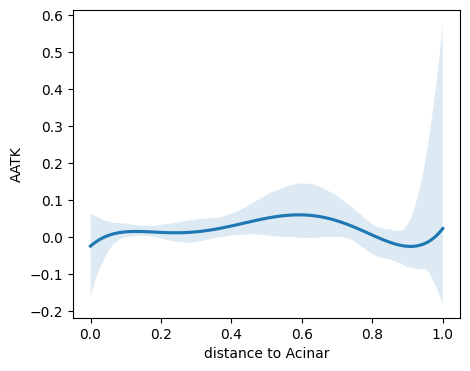

In [34]:
sq.tl.var_by_distance(
        adata=val_adata,
        groups=current_sender,
        cluster_key=cell_type_key,
        library_key="sliding_window"
)
sq.pl.var_by_distance(
    adata=val_adata,
    design_matrix_key="design_matrix",
    #var=[f'attention_values_{sender_cell}_{receiver_cell}', 'AATK'],
    var=['AATK'],
    anchor_key=current_sender,
    #line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(5, 4),
)

## Cell level evaluation

GraphCompass: https://github.com/theislab/graphcompass/blob/main/notebooks/portrait/portrait_mibitof.ipynb

In [ ]:
import graphcompass as gc

In [ ]:
library_key="sliding_window"
cluster_key="cell_type_coarse"

In [ ]:
gc.tl.distance.compare_conditions(
    adata=val_adata_list[0],
    library_key=library_key,
    cluster_key=cluster_key,
    method="portrait",
    kwargs_spatial_neighbors={
        'coord_type': 'generic',
        'delaunay': True,  
    }  
)

In [ ]:
gc.pl.distance.compare_conditions(
    adata=adata,
    library_key=library_key,
    condition_key=condition_key,
    control_group=control_group,
    # add_ncells_and_density_plots=True,
    palette="Reds",
    dpi=100,
    figsize=(10,6),
#     save="figures/mibitof_portrait.pdf"
)